# Detección de anomalías

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import csv

In [2]:
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
common_path = os.path.join(parent_dir, 'common')
common_path

'/home/juda/Documents/HIDES/colombian_case_methane_analysis-/common'

In [3]:
sat_filtered_2020_path = os.path.join(common_path, 'satellite_csv_data/colombia_prom_2020_filtered.csv')
X = pd.read_csv(sat_filtered_2020_path, usecols=['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected'])
X= X.to_numpy()
X

array([[ -77.305     ,    7.745     , 1866.55965028],
       [ -77.305     ,    7.755     , 1866.55961485],
       [ -77.295     ,    7.705     , 1866.55956703],
       ...,
       [ -67.315     ,    3.385     , 1851.07018876],
       [ -67.315     ,    3.435     , 1835.45643867],
       [ -67.315     ,    3.445     , 1835.4564209 ]])

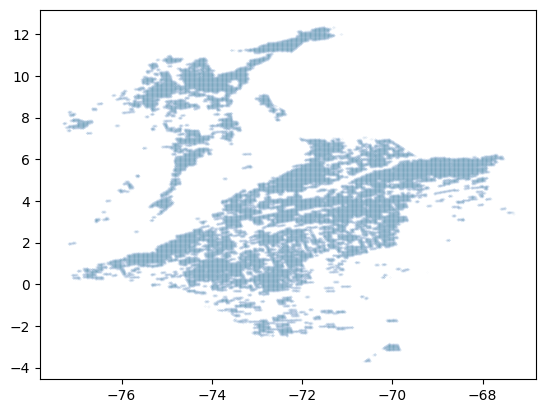

In [4]:
plt.scatter(X[:,0],X[:,1],s=0.0001)

In [4]:
def prepare_data(data, test_size=0.5):
    """
    Prepare data for machine learning by normalizing, handling NaN values,
    and splitting into training and test sets.
    
    Args:
        data: Input data array
        test_size: Proportion of data to be used for testing (default: 0.5)
        
    Returns:
        test_set: Processed test data as PyTorch tensor
        train_set: Processed training data as PyTorch tensor
        raw_data: Original data with NaN rows removed
        tensor_data: Complete processed data as PyTorch tensor
        train_indices: Original indices for training data
        test_indices: Original indices for test data
    """
    # Save a copy of the original data
    raw_data = data.copy()
    
    # Normalize the data (zero mean, unit variance)
    data -= np.mean(data, axis=0)
    data /= np.std(data, axis=0)
    
    # Remove rows with NaN values
    data = data[~np.isnan(data).any(axis=1)]
    
    # Convert to PyTorch tensor
    tensor_data = torch.tensor(data).float()
    
    # Apply the same filtering to raw data
    raw_data = raw_data[~torch.any(tensor_data.isnan(), dim=1)]
    
    # Get number of samples for splitting
    n_samples = data.shape[0]
    indices = np.arange(n_samples)
    
    # Split data into training and test sets
    train_data, test_data, train_indices, test_indices = train_test_split(
        data, indices, test_size=test_size
    )
    
    # Convert to PyTorch tensors and remove any rows with NaN values
    train_set = torch.tensor(train_data).float()
    train_set = train_set[~torch.any(train_set.isnan(), dim=1)]
    
    test_set = torch.tensor(test_data).float()
    test_set = test_set[~torch.any(test_set.isnan(), dim=1)]
    
    # Print dataset shapes for debugging
    print(f"Raw data shape: {raw_data.shape}, Test set shape: {test_set.shape}, Train set shape: {train_set.shape}")
    
    return test_set, train_set, raw_data, tensor_data, train_indices, test_indices


test_set, train_set, raw_data, tensor_data, train_indices, test_indices = prepare_data(X)

Raw data shape: (307155, 3), Test set shape: torch.Size([153578, 3]), Train set shape: torch.Size([153577, 3])


In [4]:
def prepare_data(data, test_size=0.5, random_state=42):
    """
    Prepare geospatial methane data for machine learning with improved normalization
    and data handling techniques.
    
    Args:
        data: Input data array with [lon, lat, CH4_column_values]
        test_size: Proportion of data to be used for testing (default: 0.5)
        random_state: Random seed for reproducibility
        
    Returns:
        test_set: Processed test data as PyTorch tensor
        train_set: Processed training data as PyTorch tensor
        raw_data: Original data with NaN rows removed
        tensor_data: Complete processed data as PyTorch tensor
        train_indices: Original indices for training data
        test_indices: Original indices for test data
        scaler: Fitted scaler object for inverse transformations
    """
    import numpy as np
    import torch
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import RobustScaler, MinMaxScaler
    
    # First, handle NaN values before normalization
    # Save a copy of the original data
    raw_data = data.copy()
    
    # Remove rows with NaN values
    clean_data = data[~np.isnan(data).any(axis=1)]

    n_samples = clean_data.shape[0]
    indices = np.arange(n_samples)

    # 2. Split data AND original indices together
    train_data, test_data, train_indices, test_indices = train_test_split(
        clean_data, 
        indices, 
        test_size=test_size, 
        random_state=random_state
    )


    # 3. Fit scalers on training data only
    # Coordinates scaler (-1 to 1)
    coord_scaler = MinMaxScaler(feature_range=(-1, 1))
    train_coords = coord_scaler.fit_transform(train_data[:, :2])
    
    # CH4 scaler (Robust)
    ch4_scaler = RobustScaler()
    train_ch4 = ch4_scaler.fit_transform(train_data[:, 2:])

    # 4. Apply scalers to both sets
    # Training data
    norm_train = np.hstack((
        train_coords,
        train_ch4
    ))
    
    # Test data (use transform, not fit_transform)
    test_coords = coord_scaler.transform(test_data[:, :2])
    test_ch4 = ch4_scaler.transform(test_data[:, 2:])
    norm_test = np.hstack((
        test_coords,
        test_ch4
    ))

    # Convert to tensors
    train_tensor = torch.tensor(norm_train).float()
    test_tensor = torch.tensor(norm_test).float()

    # Store normalization parameters
    normalization_params = {
        'coordinates': coord_scaler,
        'methane': ch4_scaler
    }

    
    # Print dataset shapes and statistics for verification
    print(f"Raw data shape: {raw_data.shape}")
    print(f"Clean data shape: {clean_data.shape}")
    print(f"Test set shape: {test_data.shape}, Train set shape: {train_data.shape}")
    
    return test_tensor, train_tensor, raw_data, train_indices, test_indices, normalization_params

def denormalize_predictions(normalized_data, normalization_params, methane=True):
    """
    Convert normalized predictions back to original scale using fitted scalers.
    
    Args:
        normalized_data: Normalized data (numpy array or torch tensor)
        normalization_params: Dictionary containing fitted scalers
        methane: Whether to denormalize methane values only (default: True)
        
    Returns:
        denormalized_data: Data in original scale
    """
    # Convert to numpy if it's a torch tensor
    if torch.is_tensor(normalized_data):
        normalized_data = normalized_data.detach().cpu().numpy()
    
    # Extract scalers from parameters
    coord_scaler = normalization_params['coordinates']
    ch4_scaler = normalization_params['methane']
    
    if methane:
        # Denormalize only methane values
        denorm_ch4 = ch4_scaler.inverse_transform(normalized_data)
        denorm_ch4 = denorm_ch4.flatten()
        return denorm_ch4
        
    else:
        # Split into coordinates and methane values
        norm_coords = normalized_data[:, :2]
        norm_ch4 = normalized_data[:, 2]
        
        # Denormalize each component
        denorm_coords = coord_scaler.inverse_transform(norm_coords)
        denorm_ch4 = ch4_scaler.inverse_transform(norm_ch4)
        
        # Combine back into original format
        return np.hstack((denorm_coords, denorm_ch4))



In [5]:
test_data, train_data, raw_data, train_indices, test_indices, normalization_params = prepare_data(X)

Raw data shape: (307155, 3)
Clean data shape: (307155, 3)
Test set shape: (153578, 3), Train set shape: (153577, 3)


In [6]:
test_data

tensor([[ 0.3367, -0.3167, -0.8851],
        [ 0.0822, -0.4561, -3.1695],
        [-0.2585,  0.4263,  1.1004],
        ...,
        [ 0.3387,  0.0952,  0.1431],
        [-0.5511,  0.4126,  0.4414],
        [-0.3687,  0.6378,  0.4199]])

In [7]:
class CH4AnomalyAutoencoder(nn.Module):
    """
    Autoencoder neural network specifically designed for anomaly detection.
    This architecture creates a bottleneck representation of normal data,
    which can be used to detect anomalies based on reconstruction error.
    """
    def __init__(self, input_dim, output_dim, encoding_dim=2, hidden_dims=[20, 6]):
        """
        Initialize the anomaly detection autoencoder.
        
        Args:
            input_dim: Number of input features
            encoding_dim: Size of the bottleneck layer (default: 2)
            hidden_dims: Dimensions of hidden layers in encoder/decoder (default: [20, 6])
        """
        super(CH4AnomalyAutoencoder, self).__init__()
        
        # Encoder network
        encoder_layers = []
        prev_dim = input_dim
        
        # Create encoder layers
        for dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.BatchNorm1d(dim))
            prev_dim = dim
        
        # Bottleneck layer
        encoder_layers.append(nn.Linear(prev_dim, encoding_dim))
        
        # Decoder network
        decoder_layers = []
        prev_dim = encoding_dim
        
        # Decoder: Output is 1D (CH4)
        for dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, dim))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.BatchNorm1d(dim))
            prev_dim = dim
        
        # Final layer outputs 1D (CH4)
        decoder_layers.append(nn.Linear(prev_dim, output_dim))
        
        # Create sequential models
        self.encoder = nn.Sequential(*encoder_layers)
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        """
        Forward pass through the autoencoder.
        
        Args:
            x: Input tensor
            
        Returns:
            Reconstructed input tensor
        """
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        """
        Encode the input data to the bottleneck representation.
        
        Args:
            x: Input tensor
            
        Returns:
            Encoded bottleneck representation
        """
        return self.encoder(x)
    
    def reconstruction_error(self, x):
        """
        Calculate reconstruction error for input data.
        Higher error suggests anomalies.
        
        Args:
            x: Input tensor
            
        Returns:
            Per-sample reconstruction error
        """
        # Compute error only on CH4 (third column)
        x_ch4 = x[:, 2]  # Assuming CH4 is the third feature
        reconstructed_ch4 = (self(x).float()).squeeze()  # Ensure tensor types match
        
        error = (x_ch4 - reconstructed_ch4)**2 
        
        return error

def huber_loss(y_true, y_pred, delta):
    """
    Compute the Huber loss between y_true and y_pred.
    
    Args:
        y_true: Ground truth values
        y_pred: Predicted values
        delta: Threshold parameter that determines the transition point
               between quadratic and linear loss
    
    Returns:
        Huber loss value
    """
    residual = torch.abs(y_true - y_pred)
    condition = residual < delta
    
    # Quadratic loss for small residuals, linear loss for large residuals
    loss = torch.where(condition,
                      0.5 * residual ** 2,
                      delta * (residual - 0.5 * delta))
    
    return torch.mean(loss)




def train_anomaly_detector(model, train_data, test_data=None, epochs=1000, 
                          batch_size=128, learning_rate=0.001, weight_decay=1e-7,
                          patience=20, min_delta=0.0001):
    """
    Train the anomaly detection autoencoder with early stopping.
    
    Args:
        model: Autoencoder model
        train_data: Training data (normal samples)
        test_data: Optional validation data
        epochs: Maximum number of training epochs
        batch_size: Batch size for training
        learning_rate: Learning rate for optimizer
        weight_decay: Weight decay for regularization
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change to qualify as an improvement
        
    Returns:
        Trained model and dictionary of training history
    """
    # Create data loader
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, shuffle=True
    )
    
    # Initialize optimizer with weight decay for regularization
    optimizer = torch.optim.Adam(model.parameters(), 
                                lr=learning_rate, 
                                weight_decay=weight_decay)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': []
    }
    
    # Early stopping variables
    best_loss = float('inf')
    no_improve_epochs = 0
    best_model_state = None
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            reconstructed = model(batch)
            
            # Compute loss (MSE)

            true_ch4 = batch[:, 2].unsqueeze(1)
            #loss = torch.mean(torch.sum((true_ch4 - reconstructed)**2, dim=1))
            loss = huber_loss(true_ch4, reconstructed, delta=0.05) # huber loss
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            train_loss += loss.item()
            
        # Average training loss
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Use validation loss for early stopping if available, otherwise use training loss
        current_loss = avg_train_loss
        
        # Validation if test data provided
        if test_data is not None:
            model.eval()
            with torch.no_grad():
                reconstructed = model(test_data)
                
                test_ch4 = test_data[:, 2].unsqueeze(1)
                val_loss = torch.mean(torch.sum((test_ch4 - reconstructed)**2, dim=1))
                history['val_loss'].append(val_loss.item())
                current_loss = val_loss.item()  # Use validation loss for early stopping



                # Calculate reconstruction errors with MSE first
                errors = torch.abs(test_ch4 - reconstructed)
                
                # Set delta to a percentile of these errors
                delta = torch.quantile(errors, 0.7).item()  # 70th percentile
                print(f'Delta: {delta}')
                
                # Update learning rate based on validation loss
                scheduler.step(val_loss)
            
            print(f'Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {val_loss.item():.4f}')
        else:
            print(f'Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}')
            # Update learning rate based on training loss
            scheduler.step(avg_train_loss)
        
        # Check if we have improvement
        if current_loss < best_loss - min_delta:
            best_loss = current_loss
            no_improve_epochs = 0
            # Save the best model state
            best_model_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
        else:
            no_improve_epochs += 1
            print(f'No improvement for {no_improve_epochs} epochs. Best loss: {best_loss:.4f}')
        
        # Early stopping check
        if no_improve_epochs >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            # Load the best model state
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break
    
    return model, history


def detect_anomalies(model, train_data, test_data, threshold=None, contamination=0.05, percentile=99.7):
    """
    Detect anomalies in the data using the trained autoencoder.
    
    Args:
        model: Trained autoencoder model
        data: Data to check for anomalies
        threshold: Reconstruction error threshold for anomaly detection
                  (if None, determined by contamination parameter)
        contamination: Expected proportion of anomalies in the data
                      (used to determine threshold if not provided)
    
    Returns:
        anomaly_scores: Reconstruction error for each sample
        anomaly_labels: Boolean array where True indicates an anomaly
        threshold: The threshold used for detection
    """
    model.eval()

    # After training, compute threshold on training data:
    with torch.no_grad():
        anomaly_scores = model.reconstruction_error(test_data)
        if threshold is None:
            train_errors = model.reconstruction_error(train_data)
            threshold = np.percentile(train_errors.numpy(), percentile)  # percentile of training errors
        
        # Apply threshold to test data:
        anomaly_labels = anomaly_scores > threshold

    return anomaly_scores, anomaly_labels, threshold


def visualize_anomalies(model, data, labels=None):
    """
    Visualize data in the latent space and highlight anomalies.
    
    Args:
        model: Trained autoencoder model
        data: Data to visualize
        labels: Optional anomaly labels (True for anomalies)
    
    Returns:
        Figure object
    """
    model.eval()
    
    # Get encoded representation
    with torch.no_grad():
        encoded_data = model.encode(data).detach().numpy()
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # If we have labels, color by anomaly status
    if labels is not None:
        normal = encoded_data[~labels]
        anomalies = encoded_data[labels]
        
        ax.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal', alpha=0.5)
        ax.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomaly', alpha=0.7)
    else:
        ax.scatter(encoded_data[:, 0], encoded_data[:, 1], alpha=0.5)
    
    ax.set_title('Data Points in Latent Space')
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    ax.legend()
    ax.grid(alpha=0.3)
    
    return fig

In [8]:
input_dim = X.shape[1]  # Number of features in your data
model = CH4AnomalyAutoencoder(input_dim=input_dim, output_dim=1, encoding_dim=3, hidden_dims=[32, 16, 8])

# Train the model (assuming X_tensor is your data as a PyTorch tensor)
trained_model, history = train_anomaly_detector(
    model, 
    train_data=train_data,
    test_data=test_data,
    epochs=1000
)

/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Delta: 0.05758544057607651
Epoch 1/1000 - Train Loss: 0.0044 - Val Loss: 0.0041
Delta: 0.032154083251953125
Epoch 2/1000 - Train Loss: 0.0032 - Val Loss: 0.0025
Delta: 0.038223251700401306
Epoch 3/1000 - Train Loss: 0.0029 - Val Loss: 0.0019
Delta: 0.026371031999588013
Epoch 4/1000 - Train Loss: 0.0028 - Val Loss: 0.0011
Delta: 0.038248151540756226
Epoch 5/1000 - Train Loss: 0.0026 - Val Loss: 0.0016
No improvement for 1 epochs. Best loss: 0.0011
Delta: 0.02638620138168335
Epoch 6/1000 - Train Loss: 0.0026 - Val Loss: 0.0019
No improvement for 2 epochs. Best loss: 0.0011
Delta: 0.03671085089445114
Epoch 7/1000 - Train Loss: 0.0024 - Val Loss: 0.0024
No improvement for 3 epochs. Best loss: 0.0011
Delta: 0.03794121742248535
Epoch 8/1000 - Train Loss: 0.0024 - Val Loss: 0.0013
No improvement for 4 epochs. Best loss: 0.0011
Delta: 0.046751976013183594
Epoch 9/1000 - Train Loss: 0.0025 - Val Loss: 0.0017
No improvement for 5 epochs. Best loss: 0.0011
Delta: 0.03373836353421211
Epoch 10/1000

In [9]:
from sklearn.manifold import TSNE
import umap
from mpl_toolkits.mplot3d import Axes3D

def visualize_anomalies_3d(model, data, labels=None, method='tsne', perplexity=30, n_neighbors=15, min_dist=0.1):
    """
    Visualize data in 3D latent space and highlight anomalies using dimensionality reduction.
    
    Args:
        model: Trained autoencoder model
        data: Data to visualize
        labels: Optional anomaly labels (True for anomalies)
        method: Dimensionality reduction method ('tsne' or 'umap')
        perplexity: Perplexity parameter for t-SNE
        n_neighbors: Number of neighbors for UMAP
        min_dist: Minimum distance for UMAP
    
    Returns:
        Figure object
    """
    model.eval()
    
    # Get encoded representation
    with torch.no_grad():
        encoded_data = model.encode(data).detach().numpy()
    
    # Apply dimensionality reduction if needed
    if encoded_data.shape[1] != 3:
        print(f"Reducing dimensionality from {encoded_data.shape[1]} to 3D")
        if method.lower() == 'tsne':
            reducer = TSNE(n_components=3, perplexity=perplexity, random_state=42)
            reduced_data = reducer.fit_transform(encoded_data)
        elif method.lower() == 'umap':
            reducer = umap.UMAP(n_components=3, n_neighbors=n_neighbors, 
                               min_dist=min_dist, random_state=42)
            reduced_data = reducer.fit_transform(encoded_data)
        else:
            raise ValueError("Method must be 'tsne' or 'umap'")
    else:
        reduced_data = encoded_data
    
    # Create 3D scatter plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # If we have labels, color by anomaly status
    if labels is not None:
        normal = reduced_data[~labels]
        anomalies = reduced_data[labels]
        
        ax.scatter(normal[:, 0], normal[:, 1], normal[:, 2], 
                  c='blue', label='Normal', alpha=0.5, s=30)
        ax.scatter(anomalies[:, 0], anomalies[:, 1], anomalies[:, 2], 
                  c='red', label='Anomaly', alpha=0.9, s=50, edgecolors='black')
    else:
        ax.scatter(reduced_data[:, 0], reduced_data[:, 1], reduced_data[:, 2], alpha=0.7, s=30)
    
    # Set labels and title
    method_name = "t-SNE" if method.lower() == 'tsne' else "UMAP"
    ax.set_title(f'3D Visualization of Data in Latent Space using {method_name}', fontsize=14)
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_zlabel('Dimension 3', fontsize=12)
    
    # Add legend and grid
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    
    # Improve 3D visualization
    for angle in range(0, 360, 90):
        ax.view_init(30, angle)
        plt.draw()
    
    return fig

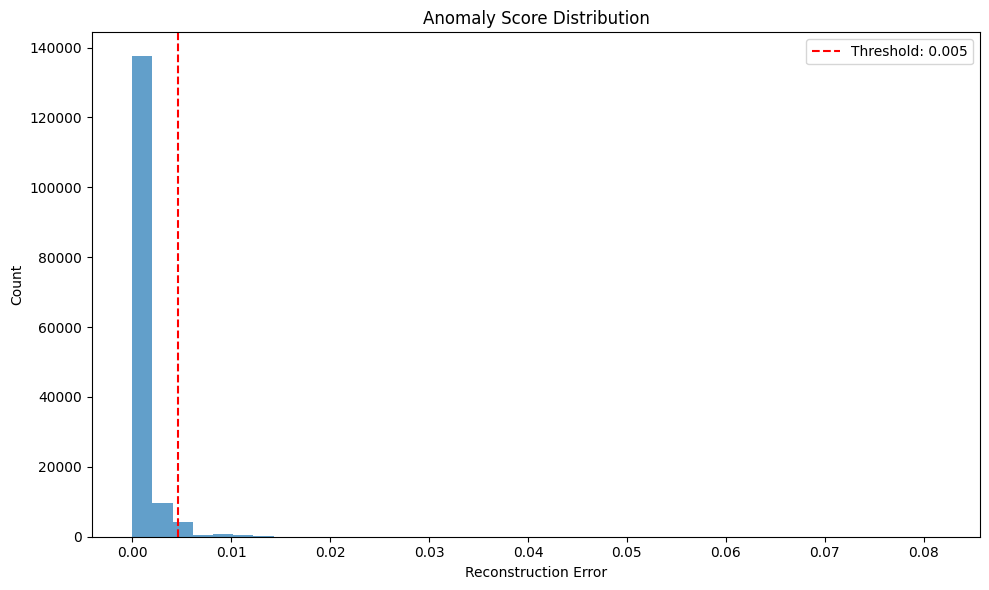

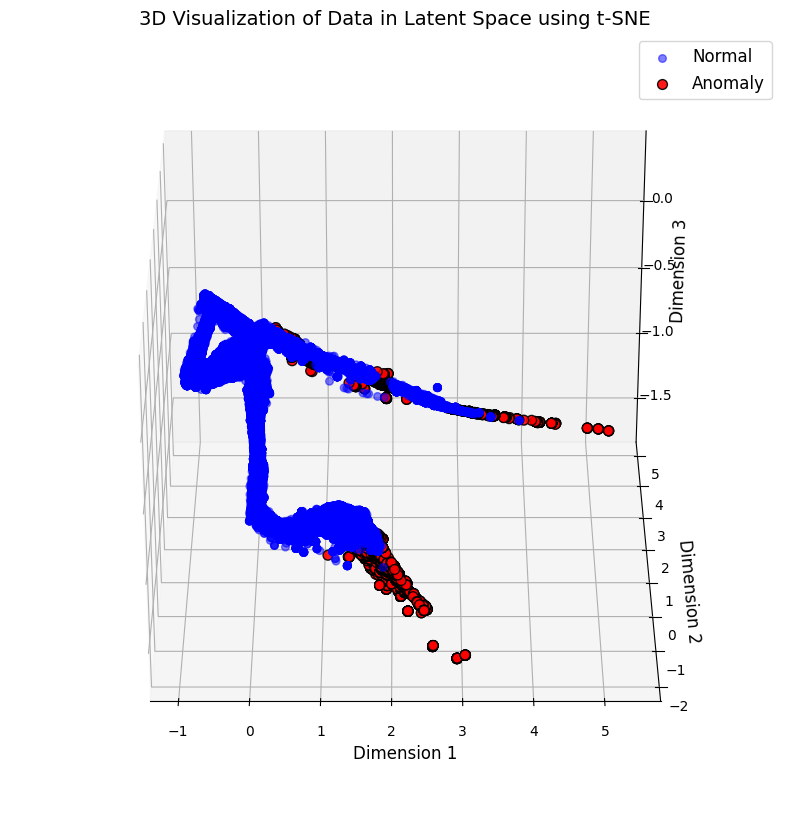

In [10]:
# Detect anomalies
anomaly_scores, anomaly_labels, threshold = detect_anomalies(
    trained_model,
    train_data=train_data,
    test_data=test_data,
    percentile=97  # Expecting 1% anomalies
)

# Visualize results
plt.figure(figsize=(10, 6))
plt.hist(anomaly_scores.numpy(), bins=40, alpha=0.7)
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.3f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.title('Anomaly Score Distribution')

# Plot 2: Visualize in latent space
#plt.subplot()
#visualize_anomalies(trained_model, test_set, anomaly_labels)
plt.tight_layout()
plt.show()

fig = visualize_anomalies_3d(trained_model, test_data, anomaly_labels, method='tsne') # umap/tsne
plt.show()

In [11]:
# Retrieve original coordinates and anomaly labels
test_original = raw_data[test_indices]
anomaly_labels_np = anomaly_labels.numpy()

# Denormalize reconstructed values
with torch.no_grad():
    reconstructed_normalized = trained_model(test_data)  # Output is normalized CH4

#reconstructed_denorm = (reconstructed_normalized.numpy().flatten() * original_std[2]) + original_mean[2]
reconstructed_denorm = denormalize_predictions(reconstructed_normalized, normalization_params)
print(reconstructed_denorm)
actual_ch4 = test_original[:,2]  # Actual CH4 values (original scale)
print(actual_ch4)
differences = actual_ch4 - reconstructed_denorm

# Classify anomalies
positive_anomalies_mask = (differences > 0) & anomaly_labels.numpy()
negative_anomalies_mask = (differences < 0) & anomaly_labels.numpy()

[1857.2423 1809.7626 1898.9935 ... 1878.7896 1884.9503 1884.3732]
[1856.79724121 1807.45605469 1899.68090998 ... 1879.00389632 1885.44689941
 1884.98212774]


In [82]:
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import geopandas as gpd
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns

# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/Departamentos_Junio_2024_shp/Departamento.shp')


# Load the departamentos shapefile into a GeoDataFrame
gdf = gpd.read_file(file_path)

GeoDataFrame already has CRS: PROJCS["MAGNA-SIRGAS_2018_Origen-Nacional",GEOGCS["MAGNA-SIRGAS_2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


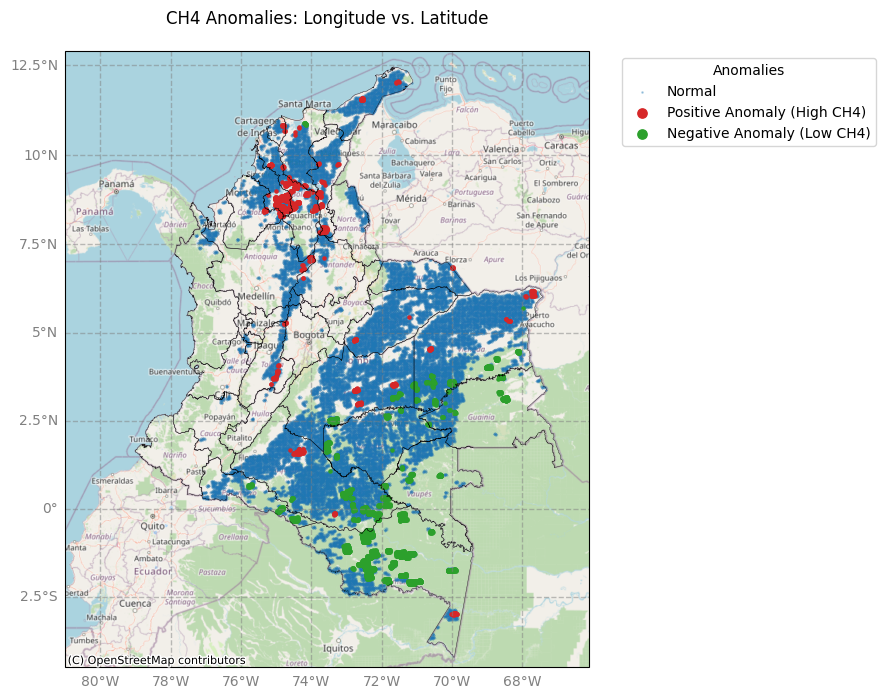

In [13]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    test_original,
    geometry=gpd.points_from_xy(test_original[:,0], test_original[:,1]),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# In the final map plot (after defining test_original and anomaly_labels):
normal_points = gdf_points.loc[~anomaly_labels_np]
positive_anomalies = gdf_points.loc[positive_anomalies_mask]
negative_anomalies = gdf_points.loc[negative_anomalies_mask]

sns_colors = sns.color_palette("tab10")

# For non-anomalies (normal points)
ax1.scatter(
    normal_points.geometry.x,  # Get x coordinates (longitude)
    normal_points.geometry.y,  # Get y coordinates (latitude)
    color=sns_colors[0],
    alpha=0.3,
    label='Normal',
    s=0.1,
    transform=ccrs.PlateCarree(),
)

# Positive anomalies (actual > predicted)
ax1.scatter(
    positive_anomalies.geometry.x,  # Get x coordinates (longitude)
    positive_anomalies.geometry.y,  # Get y coordinates (latitude)
    color=sns_colors[3],
    label='Positive Anomaly (High CH4)',
    s=5,
    transform=ccrs.PlateCarree(),
)

# Negative anomalies (actual < predicted)
ax1.scatter(
    negative_anomalies.geometry.x,  # Get x coordinates (longitude)
    negative_anomalies.geometry.y,  # Get y coordinates (latitude)
    color=sns_colors[2],
    label='Negative Anomaly (Low CH4)',
    s=5,
    transform=ccrs.PlateCarree(),
)

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map with larger points
legend = ax1.legend(
    title='Anomalies', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),
    markerscale=3  # Increase the size of points in the legend
)

# Adjust legend title font size
plt.setp(legend.get_title(), fontsize=10)



if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.8)

# Add title to map
ax1.set_title('CH4 Anomalies: Longitude vs. Latitude', pad=20)

plt.savefig('images/CH4_anomalies.png', dpi=600, bbox_inches='tight')
plt.show()


In [20]:
positive_anomalies[0]

215      -73.965
245      -70.645
246      -75.355
268      -74.625
283      -73.865
           ...  
152984   -74.925
153011   -74.485
153472   -70.605
153486   -75.185
153565   -74.625
Name: 0, Length: 1216, dtype: float64

In [29]:
# Normalizar el loss
#loss = differences
#loss = loss / np.max(abs(loss))

array([-0.44506836, -2.30651855,  0.6873797 , ...,  0.21434554,
        0.49658203,  0.60895879])

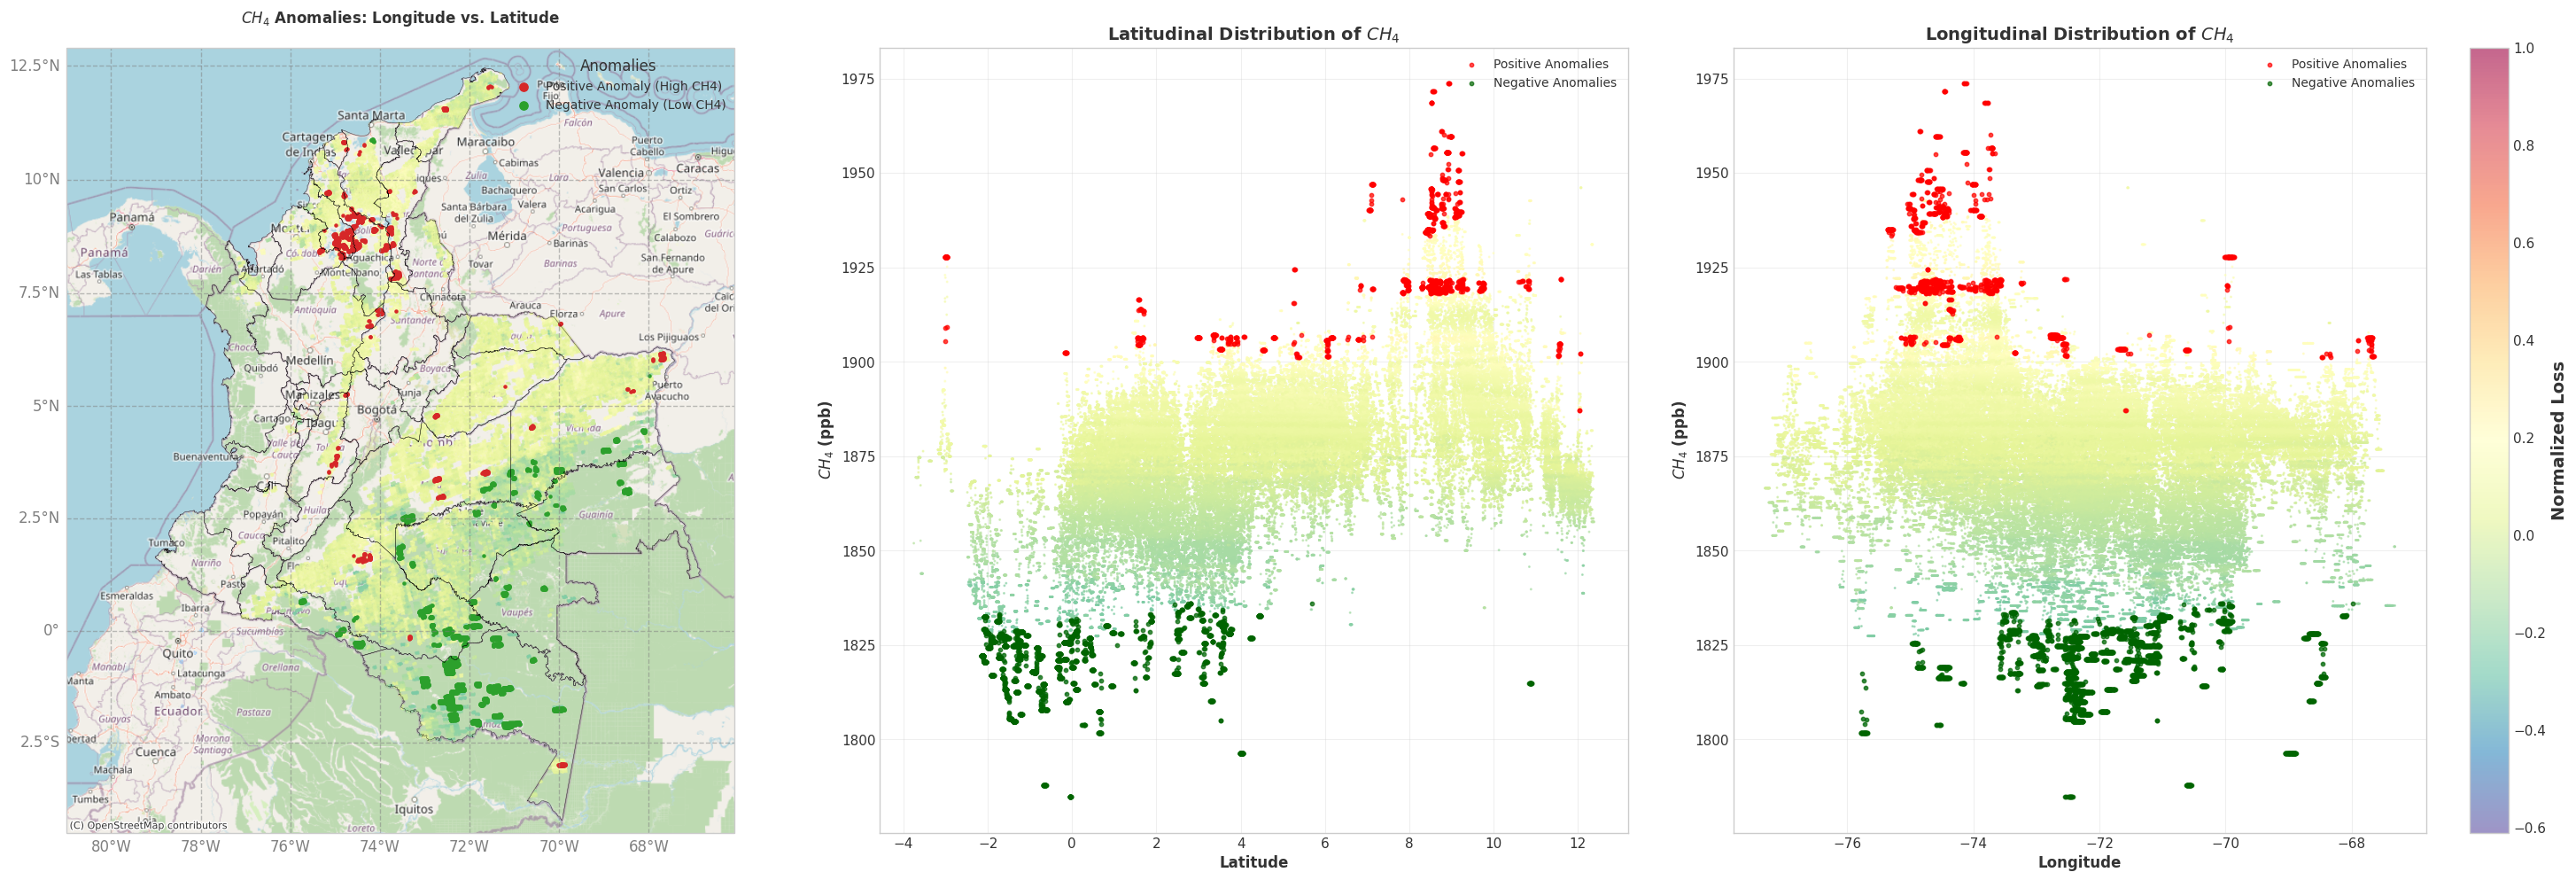

In [83]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
import seaborn as sns

# Normalización mejorada de loss
loss = differences
loss = loss/np.max(loss)
#norm = Normalize(vmin=np.percentile(loss, 0.5), vmax=np.percentile(loss, 99.5))  # quitar outliers extremos


# Crear figura con 3 columnas
fig = plt.figure(figsize=(30, 10))  # Ajusta el ancho para acomodar 3 subplots grandes
gs = GridSpec(1, 3, width_ratios=[0.95, 0.95, 1.1], figure=fig)

# --- Primer subplot: Mapa ---
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.epsg(3857))
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Preparar datos del mapa
gdf_points = gpd.GeoDataFrame(
    test_original,
    geometry=gpd.points_from_xy(test_original[:,0], test_original[:,1]),
    crs="EPSG:4326"
)
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

normal_points = gdf_points.loc[~anomaly_labels_np]
positive_anomalies = gdf_points.loc[positive_anomalies_mask]
negative_anomalies = gdf_points.loc[negative_anomalies_mask]

sns_colors = sns.color_palette("tab10")

# ax1.scatter(normal_points.geometry.x, normal_points.geometry.y,
#             color=sns_colors[0], alpha=0.3, label='Normal', s=0.1, transform=ccrs.PlateCarree())
# Plot points on map
ax1.scatter(test_original[:,0], test_original[:,1],marker='.', 
            c=loss, cmap="Spectral_r", transform=ccrs.PlateCarree(),s=0.5, alpha=0.6)
ax1.scatter(positive_anomalies.geometry.x, positive_anomalies.geometry.y,
            color=sns_colors[3], label='Positive Anomaly (High CH4)', s=5, transform=ccrs.PlateCarree())
ax1.scatter(negative_anomalies.geometry.x, negative_anomalies.geometry.y,
            color=sns_colors[2], label='Negative Anomaly (Low CH4)', s=5, transform=ccrs.PlateCarree())

cx.add_basemap(ax1, source=cx.providers.OpenStreetMap.Mapnik)

gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1,
                   color='gray', alpha=0.5, linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 12, 'color': 'gray'}
gl.ylabel_style = {'size': 12, 'color': 'gray'}

legend = ax1.legend(title='Anomalies', loc='upper left', bbox_to_anchor=(0.65, 1), markerscale=3)
plt.setp(legend.get_title(), fontsize=12)

if gdf.crs is None:
    gdf.set_crs(epsg=4326, inplace=True)
gdf = gdf.to_crs(epsg=3857)
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.8)

ax1.set_title('$CH_4$ Anomalies: Longitude vs. Latitude', pad=20)

# --- Segundo subplot: Latitud vs. CH4 ---
ax2 = fig.add_subplot(gs[0, 1])
scat2 = ax2.scatter(test_original[:,1], test_original[:,2],
                   c=loss, marker='.', cmap="Spectral_r", s=5, alpha=0.6)#, norm=norm)
ax2.scatter(positive_anomalies[1], positive_anomalies[2],
            c='red', s=10, alpha=0.7, label='Positive Anomalies')
ax2.scatter(negative_anomalies[1], negative_anomalies[2],
            c='#006400', s=10, alpha=0.7, label='Negative Anomalies')
ax2.set_xlabel("Latitude", fontsize=12)
ax2.set_ylabel("$CH_4$ (ppb)", fontsize=12)
ax2.set_title('Latitudinal Distribution of $CH_4$', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Tercer subplot: Longitud vs. CH4 ---
ax3 = fig.add_subplot(gs[0, 2])
scat3 = ax3.scatter(test_original[:,0], test_original[:,2],
                   c=loss, marker='.', cmap="Spectral_r", s=5, alpha=0.6) #, norm=norm)
ax3.scatter(positive_anomalies[0], positive_anomalies[2],
            c='red', s=10, alpha=0.7, label='Positive Anomalies')
ax3.scatter(negative_anomalies[0], negative_anomalies[2],
            c='#006400', s=10, alpha=0.7, label='Negative Anomalies')
ax3.set_xlabel("Longitude", fontsize=12)
ax3.set_ylabel("$CH_4$ (ppb)", fontsize=12)
ax3.set_title('Longitudinal Distribution of $CH_4$', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend()

# Colorbar compartida para el tercer scatter
cbar = plt.colorbar(scat3, ax=ax3)
cbar.set_label('Normalized Loss', fontsize=14)

plt.tight_layout()
plt.savefig('images/CH4_anomalies_horizontal.png', dpi=600, bbox_inches='tight')
plt.show()


# Land cover vs anomalies

```pip install -U deep-translator```


In [53]:
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
common_path = os.path.join(parent_dir, 'common')
file_path = os.path.join(common_path, 'land_cover/e_cobertura_tierra_2020_admin.shp')
# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)

In [54]:
from deep_translator import DeeplTranslator #ChatGptTranslator

mydict1={'1':'1. Artificialized territories','2':'2. Territorios agrícolas','3':'3. Bosques y áreas seminaturales','4':'4. Áreas húmedas','5':'5. Superficies de agua'}
for i in mydict1.keys():
    if i == '1':
        continue
    mydict1[i]=DeeplTranslator(api_key="REDACTED_DEEPL_KEY", source="es", target="en", use_free_api=True).translate(mydict1[i])


In [55]:
Nivel3_path = os.path.join(parent_dir, 'common/Nivel3.csv')
with open(Nivel3_path, mode='r') as infile:
    reader = csv.reader(infile)
    mydict = {rows[1]:DeeplTranslator(api_key="REDACTED_DEEPL_KEY", source="es", target="en", use_free_api=True).translate(rows[0]) for rows in reader}
mydict['142'] = '1.4.2. Recreational facilities'
mydict['214'] = '2.1.4. Vegetables'

In [56]:
gdf['Leyenda_1'] = gdf['nivel_1'].map(mydict1)
gdf['Leyenda_3'] = gdf['nivel_3'].map(mydict)
encoded_df = pd.get_dummies(gdf, columns=["Leyenda_3"])  # Encode the "leyenda 3" column
encoded_df1 = pd.get_dummies(gdf, columns=["Leyenda_1"])  # Encode the "Leyenda 1" column

encoded_df1.columns[-5:]

Index(['Leyenda_1_1. Artificialized territories',
       'Leyenda_1_2. Agricultural territories',
       'Leyenda_1_3. Forests and semi-natural areas', 'Leyenda_1_4. Wet areas',
       'Leyenda_1_5. Water surfaces'],
      dtype='object')

In [57]:
encoded_df=pd.concat([encoded_df,encoded_df1[encoded_df1.columns[-5:]]], axis=1)
encoded_df['groupb']=0
encoded_df

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Artificial water bodies,Leyenda_3_5.2.1. Coastal lagoons,Leyenda_3_5.2.2. Seas and oceans,Leyenda_3_5.2.3. Ponds for marine aquaculture,Leyenda_1_1. Artificialized territories,Leyenda_1_2. Agricultural territories,Leyenda_1_3. Forests and semi-natural areas,Leyenda_1_4. Wet areas,Leyenda_1_5. Water surfaces,groupb
0,1.0,321122,3.2.1.1.2.2. Herbazal denso inundable arbolado,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,321,...,False,False,False,False,False,False,True,False,False,0
1,2.0,3232,3.2.3.2. Vegetación secundaria baja,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
2,3.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,NaN,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
3,4.0,3231,3.2.3.1. Vegetación secundaria alta,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
4,5.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,NaN,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393463,393464.0,31112,3.1.1.1.2. Bosque denso alto inundable,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393464,393465.0,31112,3.1.1.1.2. Bosque denso alto inundable,"Landsat_2020_mediana_07042021, Landsat8_1159_0...",NaN,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393465,393466.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0
393466,393467.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0


In [58]:
l_in = list(encoded_df.columns)

In [59]:
encoded_df45 = encoded_df[~((encoded_df['Leyenda_1_4. Wet areas']>0)+(encoded_df['Leyenda_1_5. Water surfaces']>0))]
print(len(encoded_df), len(encoded_df45))

393468 382820


In [60]:
prefijos = ('Leyenda_3_4', 'Leyenda_3_5')
glint_columns = [elem for elem in l_in if elem.startswith(prefijos)]
for elem in glint_columns:
    encoded_df45 = encoded_df45[~(encoded_df45[elem]>0)]
print(len(encoded_df), len(encoded_df45))

393468 382820


In [62]:
from shapely.geometry import Point
def round_point_coordinates_numpy(geodataframe, decimals=3):
    """Round the coordinates of Point geometries using NumPy for better performance"""
    # Create a copy
    result_df = geodataframe.copy()
    
    # Extract coordinates to numpy arrays
    x_coords = np.array([point.x for point in result_df.geometry])
    y_coords = np.array([point.y for point in result_df.geometry])
    
    # Round coordinates
    x_coords_rounded = np.round(x_coords, decimals)
    y_coords_rounded = np.round(y_coords, decimals)
    
    # Create new points
    new_geometries = [Point(x, y) for x, y in zip(x_coords_rounded, y_coords_rounded)]
    
    # Assign using loc
    result_df.loc[:, 'geometry'] = new_geometries
    
    return result_df

# Apply to your geometry column
positive_anomalies = round_point_coordinates_numpy(positive_anomalies)
negative_anomalies = round_point_coordinates_numpy(negative_anomalies)
print(f"number of positive anomalies encountred: {len(positive_anomalies)}")
print(f"number of negative anomalies encountred: {len(negative_anomalies)}")

number of positive anomalies encountred: 1216
number of negative anomalies encountred: 3479


In [63]:
# Fix the CRS mismatch and optimize the spatial operations
def assign_anomaly_groups(encoded_df, positive_anomalies, negative_anomalies):
    """
    Assign group labels to points based on whether they fall within positive or negative anomaly polygons.
    
    Args:
        encoded_df: GeoDataFrame containing points to be classified
        positive_anomalies: GeoDataFrame containing positive anomaly polygons
        negative_anomalies: GeoDataFrame containing negative anomaly polygons
        
    Returns:
        encoded_df: Updated GeoDataFrame with group labels
    """
    # Make a copy to avoid modifying the original
    result_df = encoded_df.copy()
    
    # Ensure 'groupb' column exists with default value 0 (no anomaly)
    if 'groupb' not in result_df.columns:
        result_df['groupb'] = 0
    
    # Check and align CRS between dataframes
    print(f"Original CRS - Main DF: {result_df.crs}, Positive: {positive_anomalies.crs}, Negative: {negative_anomalies.crs}")

    #result_df = result_df.to_crs(positive_anomalies.crs)
    # Reproject anomaly dataframes to match the main dataframe's CRS
    print(f"length of positive anomalies: {len(positive_anomalies)}, and negatitive anomalies: {len(negative_anomalies)}")
    positive_anomalies_reprojected = positive_anomalies.to_crs(result_df.crs)
    negative_anomalies_reprojected = negative_anomalies.to_crs(result_df.crs)
    
    print(f"After reprojection - Main DF: {result_df.crs}, Positive: {positive_anomalies_reprojected.crs}, Negative: {negative_anomalies_reprojected.crs}")
    
    # For each polygon, check if it contains any point
    result_df['is_positive'] = result_df.geometry.apply(
        lambda poly: any(positive_anomalies_reprojected.geometry.within(poly))
    )
    result_df.loc[result_df['is_positive'], 'groupb'] = 1
    
    # For negative anomalies (group 2) 
    result_df['is_negative'] = result_df.geometry.apply(
        lambda poly: any(negative_anomalies_reprojected.geometry.within(poly))
    )    
    result_df.loc[result_df['is_negative'], 'groupb'] = 2
    
    # Print summary statistics
    print(f"Points in group 0 (no anomaly): {(result_df['groupb'] == 0).sum()}")
    print(f"Points in group 1 (positive anomaly): {(result_df['groupb'] == 1).sum()}")
    print(f"Points in group 2 (negative anomaly): {(result_df['groupb'] == 2).sum()}")
    
    return result_df

# Usage:
encoded_df45 = assign_anomaly_groups(encoded_df45, positive_anomalies, negative_anomalies)

Original CRS - Main DF: EPSG:4686, Positive: EPSG:4326, Negative: EPSG:4326
length of positive anomalies: 1216, and negatitive anomalies: 3479
After reprojection - Main DF: EPSG:4686, Positive: EPSG:4686, Negative: EPSG:4686


/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)
/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


Points in group 0 (no anomaly): 382034
Points in group 1 (positive anomaly): 540
Points in group 2 (negative anomaly): 246


In [64]:
encoded_df45

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.2.2. Seas and oceans,Leyenda_3_5.2.3. Ponds for marine aquaculture,Leyenda_1_1. Artificialized territories,Leyenda_1_2. Agricultural territories,Leyenda_1_3. Forests and semi-natural areas,Leyenda_1_4. Wet areas,Leyenda_1_5. Water surfaces,groupb,is_positive,is_negative
0,1.0,321122,3.2.1.1.2.2. Herbazal denso inundable arbolado,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,321,...,False,False,False,False,True,False,False,0,False,False
1,2.0,3232,3.2.3.2. Vegetación secundaria baja,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,323,...,False,False,False,False,True,False,False,0,False,False
2,3.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,NaN,SI,2,3,31,311,...,False,False,False,False,True,False,False,0,False,False
3,4.0,3231,3.2.3.1. Vegetación secundaria alta,Landsat_2020_mediana_07042021,NaN,SI,2,3,32,323,...,False,False,False,False,True,False,False,0,False,False
4,5.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,NaN,SI,2,3,31,311,...,False,False,False,False,True,False,False,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393463,393464.0,31112,3.1.1.1.2. Bosque denso alto inundable,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,1,3,31,311,...,False,False,False,False,True,False,False,0,False,False
393464,393465.0,31112,3.1.1.1.2. Bosque denso alto inundable,"Landsat_2020_mediana_07042021, Landsat8_1159_0...",NaN,SI,1,3,31,311,...,False,False,False,False,True,False,False,0,False,False
393465,393466.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,True,False,False,False,0,False,False
393466,393467.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,True,False,False,False,0,False,False


In [65]:
l_in=list(encoded_df45.columns)

pos_level3 = encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[25:-8]].aggregate('sum')
pos_level1 = encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[-8:-5]].aggregate('sum')

neg_level3=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[25:-8]].aggregate('sum')
neg_level1=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[-8:-5]].aggregate('sum')

In [66]:
neg_level1.iloc[0]

Leyenda_1_1. Artificialized territories          2
Leyenda_1_2. Agricultural territories           19
Leyenda_1_3. Forests and semi-natural areas    225
Name: 2, dtype: int64

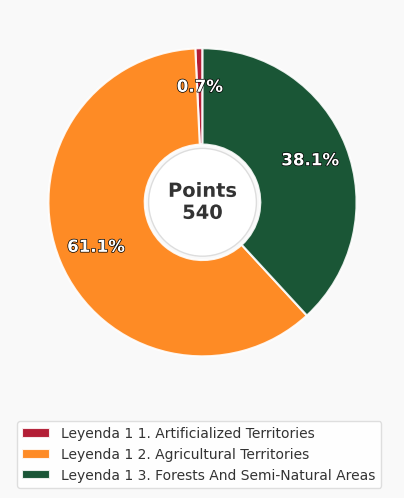

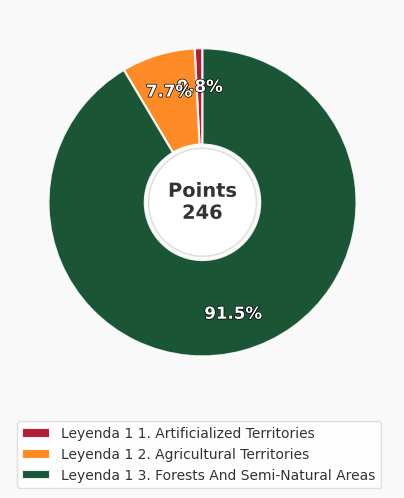

In [70]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib import rcParams

# Estilo general
plt.style.use('seaborn-v0_8-whitegrid')
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})

# Paleta de colores científica
colors = ['#AB0520', '#ff7f0e', '#014421', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Función de gráfica de pastel mejorada
def styled_pie(data, colors, labels, title, filename, explode=None):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
    fig.patch.set_facecolor('#f9f9f9')
    
    wedges, texts, autotexts = ax.pie(
        data,
        autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
        colors=colors,
        startangle=90,
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 1.5,
            'width': 0.625,
            'linestyle': '-',
            'alpha': 0.9
        },
        textprops={
            'fontsize': 12,
            'color': 'white',
            'path_effects': [path_effects.withStroke(linewidth=1, foreground="black")],
            'fontweight': 'bold'
        },
        explode=explode,
        pctdistance=0.75,
        labeldistance=1.1
    )

    # Anillo blanco en el centro
    centre_circle = plt.Circle((0, 0), 0.35, fc='white', ec='#dddddd')
    ax.add_artist(centre_circle)

    # Texto central
    text = ax.annotate(f'Points\n{sum(data):.0f}', 
                       xy=(0, 0), va='center', ha='center',
                       fontsize=14, fontweight='bold', color='#333333')
    text.set_path_effects([path_effects.withStroke(linewidth=5, foreground='white')])

    # ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_facecolor('#f9f9f9')

    # Leyenda
    ax.legend(wedges, labels,
              loc='upper left', bbox_to_anchor=(0.0, -0.05),
              ncol=1, frameon=True, framealpha=0.95,
              edgecolor='#dddddd', fontsize=10)

    # Guardado en varios formatos
    for ext, dpi in zip(['png'], [300]):
        fig.savefig(
            f'{filename}.{ext}', 
            bbox_inches='tight',
            dpi=dpi if dpi else None,
            pad_inches=0.5,
            format=ext,
            facecolor=fig.get_facecolor()
        )
    plt.show()
    plt.close()

pos_rel = pos_level1 > 1
pos_columns = pos_level1.columns[pos_rel.iloc[0]]
pos_level1_filtered = pos_level1[pos_columns]

neg_rel = neg_level1 > 1
neg_columns = neg_level1.columns[neg_rel.iloc[0]]
neg_level1_filtered = neg_level1[neg_columns]

# Clean up category names for positive anomalies
clean_pos_labels = [col[10:].replace('_', ' ').title() if col.startswith('pos_level1')
                    else col.replace('_', ' ').title() for col in pos_columns]

# Clean up category names for negative anomalies
clean_neg_labels = [col[10:].replace('_', ' ').title() if col.startswith('neg_level1')
                    else col.replace('_', ' ').title() for col in neg_columns]

# Llamadas individuales a la función para cada gráfico
styled_pie(
    data=pos_level1_filtered.iloc[0],
    colors=colors[:len(pos_columns)],
    labels=clean_pos_labels,
    title='Positive Anomaly Distribution',
    filename='positive_anomaly_distribution',
    explode=[0.0003]*len(pos_level1_filtered.iloc[0])
)

styled_pie(
    data=neg_level1_filtered.iloc[0],
    colors=colors[:len(neg_columns)],
    labels=clean_neg_labels,
    title='Negative Anomaly Distribution',
    filename='negative_anomaly_distribution',
    explode=[0.0003]*len(neg_level1_filtered.iloc[0])
)


In [77]:
total=pos_level3.iloc[0].sum()
pos_rel=pos_level3/total*100>0
pos_columns=pos_level3.columns[pos_rel.iloc[0]]
pos_level3=pos_level3[pos_columns]
pos_level3=pos_level3[pos_rel]
pos_rel=pos_level3/total*100>0
l=pos_level3/total*100
l.iloc[0].sort_values()

Leyenda_3_3.3.1. Natural sandy areas                             0.185185
Leyenda_3_3.1.5. Forest plantation                               0.185185
Leyenda_3_1.1.1. Continuous urban fabric                         0.370370
Leyenda_3_1.1.2. Discontinuous urban fabric                      0.370370
Leyenda_3_2.4.1. Crop Mosaic                                     0.370370
Leyenda_3_2.4.5. Mosaic of crops with natural areas              0.555556
Leyenda_3_3.3.3. Bare and degraded lands                         0.740741
Leyenda_3_3.1.3. Fragmented forest                               0.925926
Leyenda_3_3.3.4. Burned areas                                    1.111111
Leyenda_3_2.3.2. Wooded pastures                                 1.481481
Leyenda_3_2.2.3. Permanent tree crops                            2.037037
Leyenda_3_3.2.2. Shrubland                                       2.222222
Leyenda_3_3.1.4. Gallery and riparian forest                     3.888889
Leyenda_3_2.1.2. Cereals              

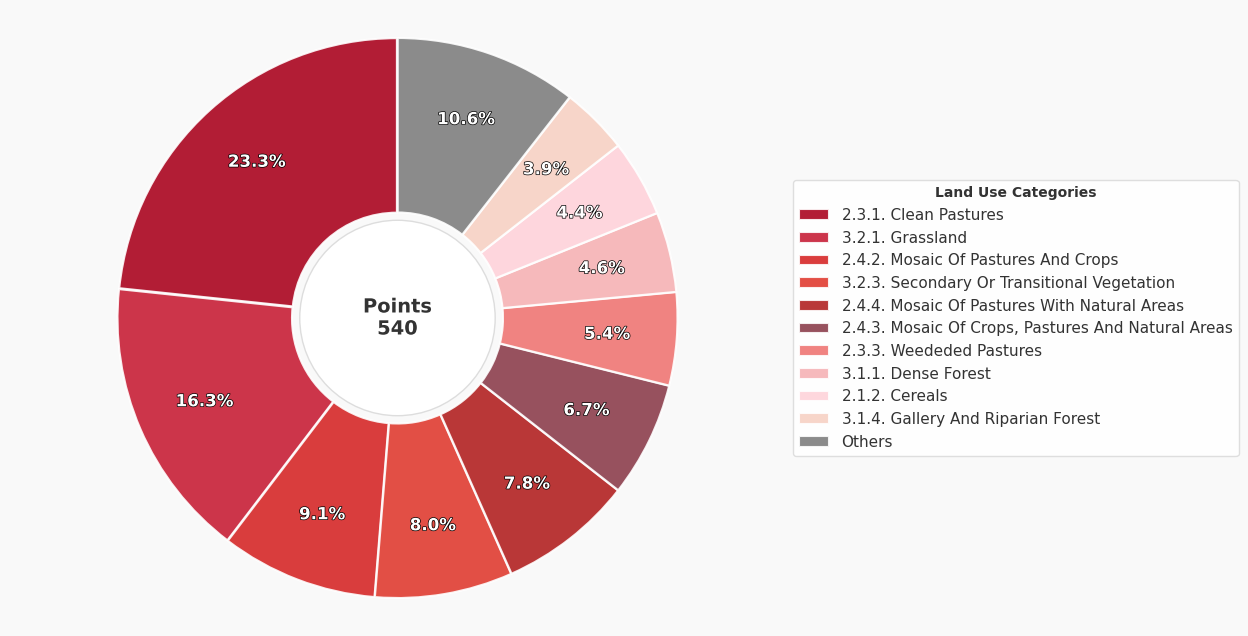

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib import rcParams
import numpy as np

# Set global style parameters with improved typography
plt.style.use('seaborn-v0_8-whitegrid')
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})

# Process data
pos_rel = pos_level3/total*100 > 3
pos_columns = pos_level3.columns[pos_rel.iloc[0]]
pos_level3_filtered = pos_level3[pos_columns]
pos_level3_filtered = pos_level3_filtered[pos_rel]

# Calculate "Others" category
others = total - pos_level3_filtered.iloc[0].sum()

# Sort values for better visualization
pos_level3_graph = pos_level3_filtered.iloc[0].sort_values(ascending=False).to_numpy()
index = np.concatenate((
    np.array([i[10:].replace('_', ' ').title() for i in 
             pos_level3_filtered.iloc[0].sort_values(ascending=False).index]),
    np.array(['Others'])
))

# Color palette (colorblind-friendly scientific palette)
#colors = ['#AB0520', '#C71F37', '#D62828', '#E03C31', '#8C3F4D', '#EF7674', '#F6B2B5', '#FFD3DA', '#F7D1C4', '#7f7f7f']
colors = ['#AB0520', '#C71F37', '#D62828', '#E03C31', '#B22222', '#8C3F4D', '#EF7674', '#F6B2B5', '#FFD3DA', '#F7D1C4', '#7f7f7f']

# Create figure with adjusted layout
fig = plt.figure(figsize=(10, 8), dpi=100)  # Larger size for better readability

# Function for styled pie chart to match previous graphs
def styled_pie(ax, data, colors, labels, title, explode=None):
    wedges, texts, autotexts = ax.pie(
        data,
        autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
        colors=colors,
        startangle=90,
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 1.5,
            'width': 0.625,
            'linestyle': '-',
            'alpha': 0.9
        },
        textprops={
            'fontsize': 12,
            'color': 'white',
            'path_effects': [path_effects.withStroke(linewidth=1, foreground="black")],
            'fontweight': 'bold'
        },
        explode=explode,
        pctdistance=0.75,
        labeldistance=1.1
    )
    
    # Center annotation with shadow effect
    centre_circle = plt.Circle((0,0), 0.35, fc='white', ec='#dddddd')
    ax.add_artist(centre_circle)
    
    # Total count with shadow effect
    text = ax.annotate(f'Points\n{sum(data):.0f}', 
                xy=(0, 0), 
                va='center', 
                ha='center',
                fontsize=14, 
                fontweight='bold',
                color='#333333')
    text.set_path_effects([path_effects.withStroke(linewidth=5, foreground='white')])
    
    # ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Add subtle background
    ax.set_facecolor('#f9f9f9')
    
    return wedges

# Main plot area
ax = fig.add_subplot(1, 1, 1)

# Create data array with Others at the end for better visual hierarchy
data = np.concatenate((pos_level3_graph, np.array([others])))

# Create explode array (slightly separate each slice)
explode = [0.003] * len(index)

# Create the styled pie chart
wedges = styled_pie(
    ax,
    data,
    colors=colors[:len(index)],
    labels=index,
    title='Distribution of Positive Anomalies by Land Use (Level 3)',
    explode=explode
)

# Add legend with enhanced styling
legend = ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.95,
    edgecolor='#dddddd',
    fontsize=11
)
legend.get_title().set_fontweight('bold')

# Add methodology note with enhanced styling
# note_text = ax.annotate(
#     'Note: Only categories representing >3% of total area are shown individually',
#     xy=(0.5, -0.05), 
#     xycoords='axes fraction',
#     ha='center', 
#     va='center', 
#     fontsize=11, 
#     fontstyle='italic',
#     color='#555555'
# )

# note_text.set_path_effects([path_effects.withStroke(linewidth=5, foreground='white')])

# Add figure title with subtle background
fig.patch.set_facecolor('#f9f9f9')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure in multiple formats for publication
plt.savefig(
    'Distribution_of_Positive_Anomalies_by_Land_Use_(Level_3).png',
    bbox_inches='tight',
    dpi=300,
    pad_inches=0.5,
    facecolor=fig.get_facecolor()
)

plt.show()

In [74]:
total=neg_level3.iloc[0].sum()
neg_rel=neg_level3/total*100>0
neg_columns=neg_level3.columns[neg_rel.iloc[0]]
neg_level3=neg_level3[neg_columns]
neg_level3=neg_level3[neg_rel]
neg_rel=neg_level3/total*100>0
l=neg_level3/total*100
l.iloc[0].sort_values()

Leyenda_3_1.1.1. Continuous urban fabric                         0.406504
Leyenda_3_1.1.2. Discontinuous urban fabric                      0.406504
Leyenda_3_2.2.3. Permanent tree crops                            0.406504
Leyenda_3_2.4.2. Mosaic of pastures and crops                    0.406504
Leyenda_3_2.2.1. Permanent herbaceous crops                      0.813008
Leyenda_3_3.2.2. Shrubland                                       0.813008
Leyenda_3_2.3.1. Clean pastures                                  1.626016
Leyenda_3_2.4.4. Mosaic of pastures with natural areas           1.626016
Leyenda_3_3.1.4. Gallery and riparian forest                     1.626016
Leyenda_3_2.4.3. Mosaic of crops, pastures and natural areas     2.845528
Leyenda_3_3.1.3. Fragmented forest                               6.097561
Leyenda_3_3.2.3. Secondary or transitional vegetation           10.975610
Leyenda_3_3.2.1. Grassland                                      15.040650
Leyenda_3_3.1.1. Dense forest         

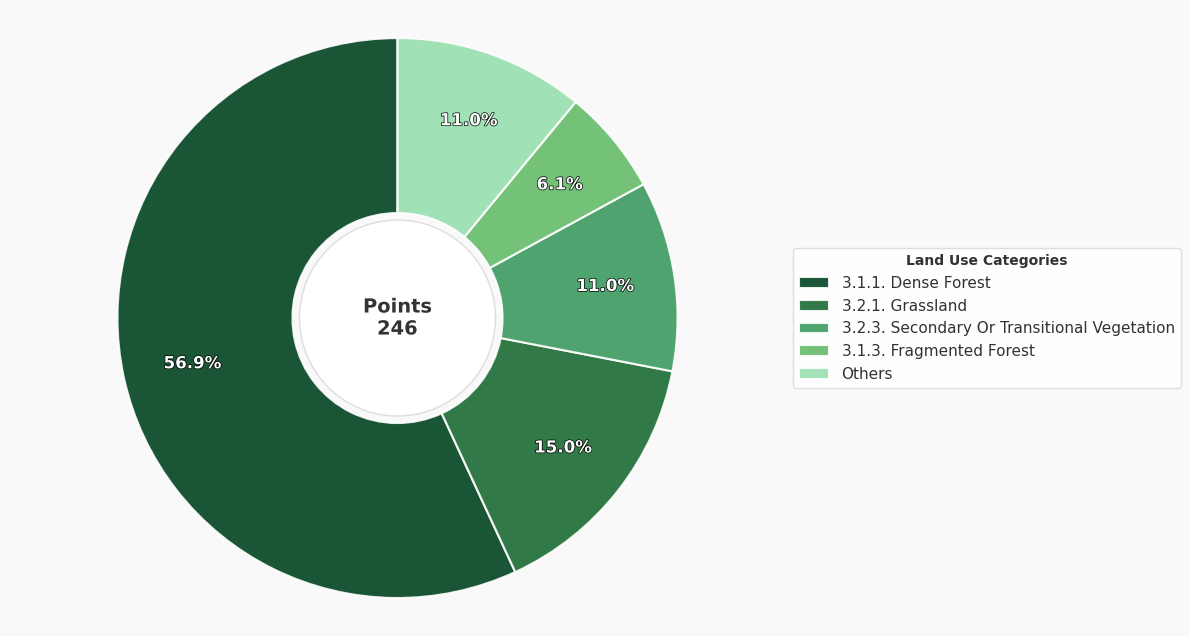

In [75]:
# Process data
neg_rel = neg_level3/total*100 > 4
neg_columns = neg_level3.columns[neg_rel.iloc[0]]
neg_level3_filtered = neg_level3[neg_columns]
neg_level3_filtered = neg_level3_filtered[neg_rel]

# Calculate "Others" category
others = total - neg_level3_filtered.iloc[0].sum()

# Sort values for better visualization - descending order with "Others" at the end
neg_level3_graph = neg_level3_filtered.iloc[0].sort_values(ascending=False).to_numpy()
index = np.concatenate((
    np.array([i[10:].replace('_', ' ').title() for i in 
             neg_level3_filtered.iloc[0].sort_values(ascending=False).index]),
    np.array(['Others'])
))

# Create figure with adjusted layout
fig = plt.figure(figsize=(10, 8), dpi=100)  # Larger size for better readability

# Color palette - use reds for negative anomalies (professional shades)
#colors = ['#AB0520', '#C71F37', '#E03C31', '#EF7674', '#F6B2B5', '#F7D1C4', '#7f7f7f']
colors = ['#014421', '#1B6B32', '#3C9A5F', '#66BB6A', '#98DFAF', '#C7EFCF', '#E9FBE5']

# Function for styled pie chart to match previous graphs
def styled_pie(ax, data, colors, labels, title, explode=None):
    wedges, texts, autotexts = ax.pie(
        data,
        autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
        colors=colors,
        startangle=90,
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 1.5,
            'width': 0.625,
            'linestyle': '-',
            'alpha': 0.9
        },
        textprops={
            'fontsize': 12,
            'color': 'white',
            'path_effects': [path_effects.withStroke(linewidth=1, foreground="black")],
            'fontweight': 'bold'
        },
        explode=explode,
        pctdistance=0.75,
        labeldistance=1.1
    )
    
    # Center annotation with shadow effect
    centre_circle = plt.Circle((0,0), 0.35, fc='white', ec='#dddddd')
    ax.add_artist(centre_circle)
    
    # Total count with shadow effect
    text = ax.annotate(f'Points\n{sum(data):.0f}', 
                xy=(0, 0), 
                va='center', 
                ha='center',
                fontsize=14, 
                fontweight='bold',
                color='#333333')
    text.set_path_effects([path_effects.withStroke(linewidth=5, foreground='white')])
    
    # ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Add subtle background
    ax.set_facecolor('#f9f9f9')
    
    return wedges

# Main plot area
ax = fig.add_subplot(1, 1, 1)

# Create data array with Others at the end
data = np.concatenate((neg_level3_graph, np.array([others])))

# Create explode array (slightly separate each slice)
explode = [0.0003] * len(index)

# Create the styled pie chart
wedges = styled_pie(
    ax,
    data,
    colors=colors[:len(index)],
    labels=index,
    title='Distribution of Negative Anomalies by Land Use (Level 3)',
    explode=explode
)

# Add legend with enhanced styling
legend = ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.95,
    edgecolor='#dddddd',
    fontsize=11
)
legend.get_title().set_fontweight('bold')

# Add methodology note with enhanced styling
# note_text = ax.annotate(
#     'Note: Only categories representing >4% of total area are shown individually',
#     xy=(0.5, -0.05), 
#     xycoords='axes fraction',
#     ha='center', 
#     va='center', 
#     fontsize=11, 
#     fontstyle='italic',
#     color='#555555'
# )
# note_text.set_path_effects([path_effects.withStroke(linewidth=5, foreground='white')])

# Add figure title with subtle background
fig.patch.set_facecolor('#f9f9f9')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure in multiple formats for publication
plt.savefig(
    'Distribution_of_Negative_Anomalies_by_Land_Use_(Level_3).png',
    bbox_inches='tight',
    dpi=300,
    pad_inches=0.5,
    facecolor=fig.get_facecolor()
)

plt.show()